In [1]:
import scipy
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from collections import namedtuple
from typing import NamedTuple
from functools import partial

import boid

In [2]:
rng = np.random.default_rng(42)
N   = 1000

pos  = rng.standard_normal((N, 3))
vel  = rng.standard_normal((N, 3))
mass = rng.uniform(0.5, 2.0, N)
charge = rng.uniform(-1,1,N)

tree, n_nodes = boid.build_flat_tree(pos, vel, mass, charge)

print(f"N particles : {N}")
print(f"Nodes used  : {n_nodes}  (ratio {n_nodes/N:.2f}x)")
print(f"Tree depth  : ~{np.ceil(np.log(N)/np.log(8)):.0f} levels")

# ── Check 1: root mass equals sum of all particle masses ────────────
root_mass = tree.mass[0]
expected  = mass.sum()
assert np.isclose(root_mass, expected), \
    f"Root mass mismatch: {root_mass} vs {expected}"
print(f"Root mass check       : PASSED  ({root_mass:.4f})")

# ── Check 2: root COM equals particle-weighted average ──────────────
expected_com = (pos * mass[:, None]).sum(axis=0) / mass.sum()
assert np.allclose(tree.com_xyz[0], expected_com, atol=1e-10), \
    f"Root COM mismatch: {tree.com_xyz[0]} vs {expected_com}"
print(f"Root COM check        : PASSED  ({tree.com_xyz[0]})")

# ── Check 3: every leaf references a valid particle ─────────────────
leaf_mask     = tree.is_leaf
leaf_particles = tree.particle[leaf_mask]
assert (leaf_particles >= 0).all(), "Leaf with no particle index"
assert len(np.unique(leaf_particles)) == N, \
    f"Expected {N} unique particles at leaves, got {len(np.unique(leaf_particles))}"
print(f"Leaf particle check   : PASSED  ({leaf_mask.sum()} leaves for {N} particles)")

# ── Check 4: all children indices are in-bounds ─────────────────────
valid_children = tree.children[tree.children != -1]
assert (valid_children < n_nodes).all(), "Child index out of bounds"
print(f"Children bounds check : PASSED")

print("\nAll checks passed.")


N particles : 1000
Nodes used  : 1494  (ratio 1.49x)
Tree depth  : ~4 levels
Root mass check       : PASSED  (1252.6088)
Root COM check        : PASSED  ([-0.00827713 -0.02987993 -0.04124482])
Leaf particle check   : PASSED  (1000 leaves for 1000 particles)
Children bounds check : PASSED

All checks passed.


In [16]:
MAX_STACK = 128
def force_equation(r,pos_i, mass_t, mass_i, charge_t, charge_i, r_vec, vel_t, vel_i, time):
    return charge_i*charge_t*jnp.cross(vel_i,jnp.cross(vel_t,r_vec))/r**3/mass_i

jax.jit
def force_on_one(i, pos_i, vel_i, mass_i, charge_i, time, tree, theta, softening): 
    # State: (accel_accumulator, stack_array, stack_pointer) 
    init = ( jnp.zeros(3), # accel accumulator 
             jnp.zeros(MAX_STACK, dtype=jnp.int32).at[0].set(0), # stack, root at [0] 
             jnp.int32(1), # stack pointer (1 item: root) 
           )
    def cond(state): 
        _, _, sp = state 
        return sp > 0 # loop while stack non-empty
    def body(state): 
        accel, stack, sp = state 
        sp -= 1 
        node = stack[sp] # pop current node
        r_vec = pos_i - tree.com_xyz[node]
        r = jnp.sqrt(jnp.dot(r_vec, r_vec) + softening**2) 
        ratio = 2.0 * tree.half_w[node] / r
        
        is_self = tree.is_leaf[node] & (tree.particle[node] == i) # skip self-interaction 
        approx = tree.is_leaf[node] | (ratio < theta)
        # --- Compute contribution if approximating (or exact leaf) --- 
        force_total = force_equation(r, pos_i, tree.mass[node], mass_i, tree.charge[node], charge_i, r_vec, tree.coc_vel[node], vel_i, time)
        contrib = jnp.where(approx & ~is_self, force_total, jnp.zeros(3)) 
        accel += contrib
        # --- Push children onto stack if not approximating --- 
        should_recurse = ~approx & ~is_self 
        for c in range(8): # unrolled — static count 
            child = tree.children[node, c] 
            valid = should_recurse & (child != -1) 
            stack = jnp.where(valid, stack.at[sp].set(child), stack) 
            sp += jnp.where(valid, 1, 0)
        return accel, stack, sp
    accel_final, _, _ = jax.lax.while_loop(cond, body, init) 
    return accel_final

In [17]:
# vmap maps force_on_one over the particle axis in parallel. # in_axes=(0,0,0,0,None,None,None): first 4 args are per-particle, # tree/theta/softening are shared across all particles. 
force_all_particles = jax.vmap( force_on_one, in_axes=(0, 0, 0, 0, 0, None, None, None, None) ) # i, pos_i, vel_i, mass_i, tree, θ, ε ) parallel over N
# Wrap the full derivatives in jit for XLA compilation 
@jax.jit 
def compute_accels_jax(pos, vel, mass, charge, time, tree, theta, softening): 
    particle_ids = jnp.arange(len(pos), dtype=jnp.int32) 
    return force_all_particles(particle_ids, pos, vel, mass, charge, time, tree, theta, softening)

In [18]:
def derivatives(t, state,mass,charge,theta,softening): 
    
    pos_np, vel_np = boid.unpack(state, len(mass)) # numpy, on CPU
    # Step 1: build flat octree on CPU — O(N log N), numpy 
    tree, n_nodes = boid.build_flat_tree(pos_np, vel_np, mass, charge)# CPU
    # Step 2: ship tree + state to device 
    tree = boid.tree_to_device(tree) #host → device 
    pos_jnp = jnp.array(pos_np) 
    vel_jnp = jnp.array(vel_np)
    mass_jnp = jnp.array(mass) 
    charge_jnp = jnp.array(charge)
    # Step 3: compute all accelerations in parallel on device 
    accel_jnp = compute_accels_jax( pos_jnp, vel_jnp, mass_jnp, charge_jnp, jnp.array(t), tree, theta, softening)
    # Step 4: pull result back to CPU for scipy 
    accel_np = np.array(accel_jnp) 
    return boid.pack(vel_np, accel_np)

In [20]:
trange=np.linspace(0,np.pi)
mass= np.array([1.0,1.0])
charge = np.array([1.0,1.0])
pos0 = np.array([[-1,0.1,0],
                [1,-0.1,0]])
vel0 = np.array([[0.3,0,0],
                [-0.3,0,0]])
state0 = boid.pack(pos0,vel0)
theta = 0.7
softening = 1e-10

sol = scipy.integrate.solve_ivp(derivatives,(trange.min(),trange.max()),state0,args=(mass,charge,theta,softening),t_eval=trange)

(12, 50)
(2, 3, 50)


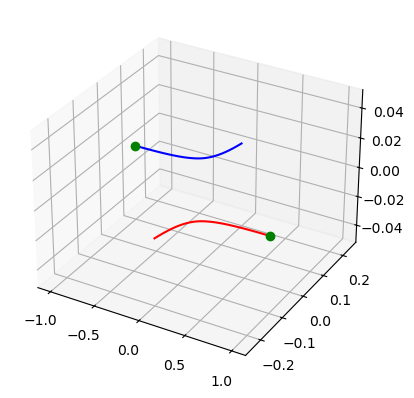

In [21]:
print(sol.y.shape)
pos,vel = np.apply_along_axis(boid.unpack,0,sol.y,len(mass))
print(pos.shape)
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot3D(pos[0,0,:],pos[0,1,:],pos[0,2,:], 'blue')
ax.plot3D(pos[1,0,:],pos[1,1,:],pos[1,2,:], 'red')
ax.plot3D(pos0[0,0],pos0[0,1],pos0[0,2], 'green',marker='o')
ax.plot3D(pos0[1,0],pos0[1,1],pos0[1,2], 'green',marker='o')


plt.show()

In [22]:
trange=np.linspace(0,2*np.pi/12,20)
mass= np.array([1.0,1.0])
charge = np.array([1e0,1e0])
pos0 = np.array([[-1,0.05,0],
                [-1,-0.05,0]])
vel0 = np.array([[0.1,0,0],
                [0.1,0,0]])
state0 = boid.pack(pos0,vel0)
theta = 0.7
softening = 1e-10

sol = scipy.integrate.solve_ivp(derivatives,(trange.min(),trange.max()),state0,args=(mass,charge,theta,softening),t_eval=trange)

(12, 20)
(2, 3, 20)


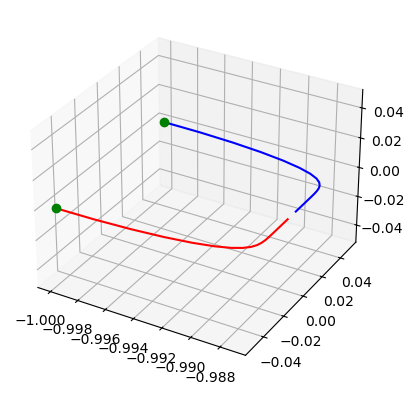

In [23]:
print(sol.y.shape)
pos,vel = np.apply_along_axis(boid.unpack,0,sol.y,len(mass))
print(pos.shape)
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot3D(pos[0,0,:],pos[0,1,:],pos[0,2,:], 'blue')
ax.plot3D(pos[1,0,:],pos[1,1,:],pos[1,2,:], 'red')
ax.plot3D(pos0[0,0],pos0[0,1],pos0[0,2], 'green',marker='o')
ax.plot3D(pos0[1,0],pos0[1,1],pos0[1,2], 'green',marker='o')


plt.show()

In [24]:
rng    = np.random.default_rng(42)
N      = 10
mass   = np.ones(N)
charge = np.ones(N)   # like charges

pos0   = (rng.standard_normal((N, 3))*0.1) - 1
vel0   = rng.standard_normal((N, 3))*0.01 + 0.1
state0 = np.concatenate([pos0.ravel(), vel0.ravel()])

# Each instance compiles its own XLA program — swap force law by
# constructing a different simulator, no code changes anywhere else
sim_magnetic = boid.BarnesHutSimulator(mass, charge, force_equation)

sol = scipy.integrate.solve_ivp(
    sim_magnetic.derivatives,
    t_span=(0, 1.0),
    y0=state0,
    method='RK45',
    rtol=1e-6, atol=1e-9,
)
print(f"Coulomb run: {sol.t.shape[0]} time steps, success={sol.success}")

Coulomb run: 351 time steps, success=True


(60, 351)
(10, 3, 351)


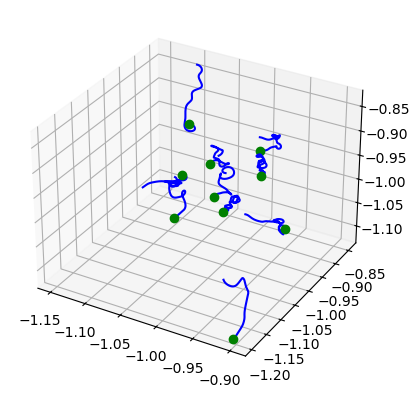

In [26]:
print(sol.y.shape)
pos,vel = np.apply_along_axis(boid.unpack,0,sol.y,len(mass))
np.savetxt("randmag.csv", pos[0,:,:].T, delimiter=",")
print(pos.shape)
fig = plt.figure()
ax = plt.axes(projection='3d')

for ii in range(pos.shape[0]):
    ax.plot3D(pos[ii,0,:],pos[ii,1,:],pos[ii,2,:], 'blue')
    ax.plot3D(pos0[ii,0],pos0[ii,1],pos0[ii,2], 'green',marker='o')


plt.show()

In [34]:
class DipoleEquation:
    def __init__(self,dipole_mag,dipole_pos):
        self.dipole_mag = dipole_mag
        self.dipole_pos = dipole_pos

    @partial(jax.jit,static_argnums=(0))
    def __call__(self,r, pos_i, mass_t, mass_i, charge_t, charge_i, r_vec, vel_t, vel_i, time):
        rdip = pos_i - self.dipole_pos
        rdiphat = rdip / jnp.sqrt(jnp.dot(rdip,rdip))
        B_charges = jnp.cross(charge_t*vel_t,r_vec)/r**3
        B_dipole = (3*rdiphat*(jnp.dot(rdiphat,self.dipole_mag)) - self.dipole_mag)/jnp.sqrt(jnp.dot(rdip,rdip))**3
        return jnp.cross(charge_i*vel_i,B_charges + B_dipole)/mass_i
dipole_equation = DipoleEquation(jnp.array([0,0,1]),jnp.array([0,0,0]))


In [206]:
trange=np.linspace(0,2*np.pi,100)

rng    = np.random.default_rng(42)
N      = 10
mass   = np.ones(N)
charge = np.ones(N)   # like charges

pos0   = (rng.standard_normal((N, 3))*np.array([np.sqrt(1/(4*np.pi)),.01,.01])[None,:]) + np.array([1,0,0])[None,:]
vel0   = (rng.standard_normal((N, 3))*np.array([0.01,.1,.01])[None,:]) + np.array([0,1,0])[None,:]
state0 = np.concatenate([pos0.ravel(), vel0.ravel()])

# Each instance compiles its own XLA program — swap force law by
# constructing a different simulator, no code changes anywhere else
sim_magnetic = boid.BarnesHutSimulator(mass, charge, dipole_equation)

sol = scipy.integrate.solve_ivp(
    sim_magnetic.derivatives,
    t_span=(trange.min(), trange.max()),
    y0=state0,
    method='RK45',
    rtol=1e-6, atol=1e-9,
    t_eval = trange
)
print(f"Coulomb run: {sol.t.shape[0]} time steps, success={sol.success}")

Coulomb run: 100 time steps, success=True


(60, 100)
(10, 3, 100)


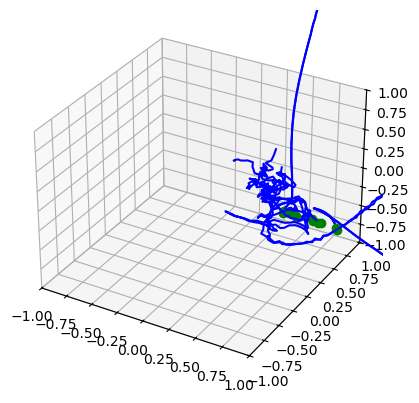

In [208]:
print(sol.y.shape)
pos,vel = np.apply_along_axis(boid.unpack,0,sol.y,len(mass))
np.savetxt("randmag.csv", pos[0,:,:].T, delimiter=",")
print(pos.shape)
fig = plt.figure()
ax = plt.axes(projection='3d')

for ii in range(pos.shape[0]):
    ax.plot3D(pos[ii,0,:],pos[ii,1,:],pos[ii,2,:], 'blue')
    ax.plot3D(pos0[ii,0],pos0[ii,1],pos0[ii,2], 'green',marker='o')

width = 1
ax.set_xlim(-width,width)
ax.set_ylim(-width,width)
ax.set_zlim(-width,width)


plt.show()

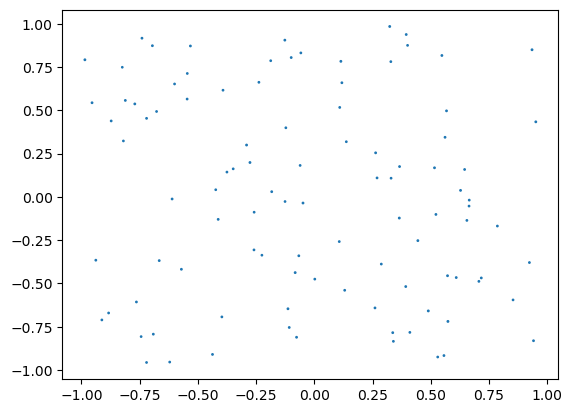

In [ ]:
rng    = np.random.default_rng(42)
number_stars = 100
x = rng.uniform(-1,1,size=number_stars)
y = rng.uniform(-1,1,size=number_stars)
mag = rng.standard_normal((number_stars))*0.05 + 1
plt.scatter(x,y,s=mag)
plt.show()

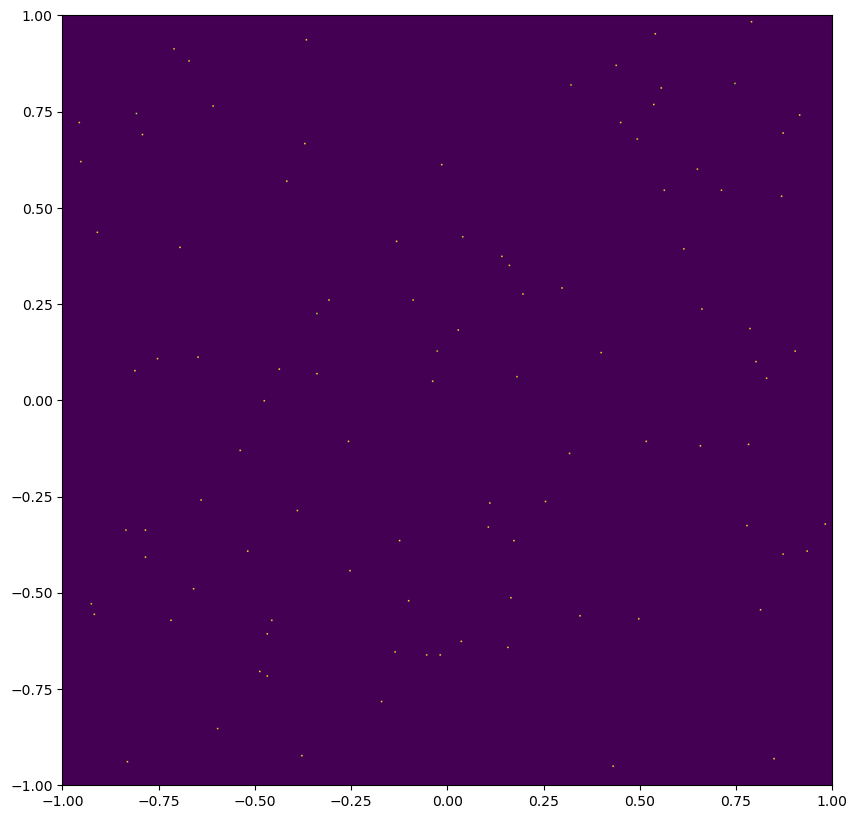

1.1452533584620204 0.0
[-0.0625     -0.05846774 -0.05443548 -0.05040323 -0.04637097 -0.04233871
 -0.03830645 -0.03427419 -0.03024194 -0.02620968 -0.02217742 -0.01814516
 -0.0141129  -0.01008065 -0.00604839 -0.00201613  0.00201613  0.00604839
  0.01008065  0.0141129   0.01814516  0.02217742  0.02620968  0.03024194
  0.03427419  0.03830645  0.04233871  0.04637097  0.05040323  0.05443548
  0.05846774  0.0625    ]
105.93092115490187 0.0


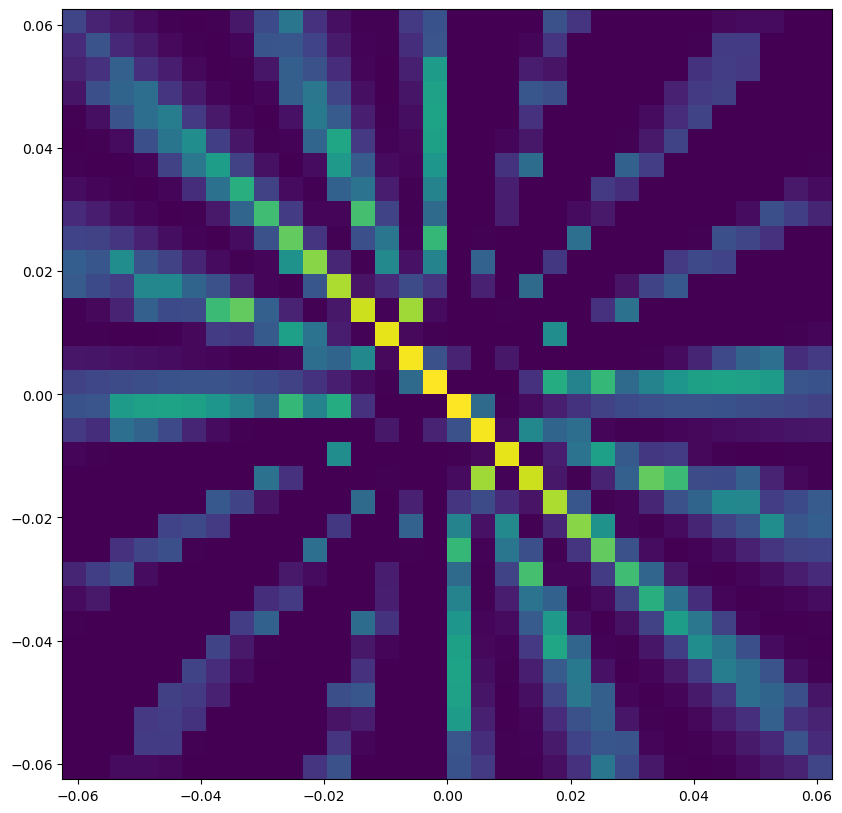

In [108]:
def make_top_image(xs,ys,x,y,mag):
    z = np.zeros((xs.shape[0],ys.shape[0]))
    for xpt,ypt,magpt in zip(x,y,mag):
        i = np.abs(xs - xpt).argmin()
        j = np.abs(ys - ypt).argmin()

        z[i,j] = magpt
    return z

number_spikes = 17
theta_sigma = 0.06
r_sigma= 0.05
def spike_kernel(x,y):
    epsilon=1e-6
    theta = jnp.where(jnp.isclose(x,0),jnp.arctan(y/epsilon),jnp.arctan(y/x))
        
    r = np.sqrt(x**2 + y**2)
    thetas= np.linspace(0,2*np.pi,number_spikes)
    theta_part = np.zeros(x.shape)
    for theta_dir in thetas:
        theta_part += gaussian_function((theta-theta_dir),sigma=theta_sigma) +  gaussian_function(-(theta-theta_dir) % 2*np.pi,sigma=theta_sigma)
    z = gaussian_function(r,sigma=r_sigma) * theta_part
    return z

def gaussian_function(x,sigma):
    return np.exp(-(x**2)/(2*sigma**2)) / (sigma * np.sqrt(2*np.pi))

def con_kernel(x,y):
    return np.exp(-(x**2 + y**2)/(2*sigma**2)) / (sigma * np.sqrt(2*np.pi))

xs = np.linspace(-1,1,512)
z = make_top_image(xs,xs,x,y,mag)

plt.figure(figsize=(10, 10)) 
ax = plt.imshow(z,vmin=0,vmax=1,extent=(xs.min(),xs.max(),xs.min(),xs.max()))
# plt.scatter(-x,-y,alpha=0.1)
plt.show()
print(z.max(),z.min())


scale_down = 16
x_kern = np.linspace(-1/scale_down,1/scale_down,int(len(xs)/scale_down))

Xs, Ys = np.meshgrid(x_kern,x_kern)
kernel = spike_kernel(Xs,Ys)
print(x_kern)
print(kernel.max(),kernel.min())

plt.figure(figsize=(10, 10)) 
plt.imshow(kernel,extent=(x_kern.min(),x_kern.max(),x_kern.min(),x_kern.max()))
plt.show()


In [109]:
image = scipy.signal.convolve2d(z,kernel,mode='same',boundary='wrap')

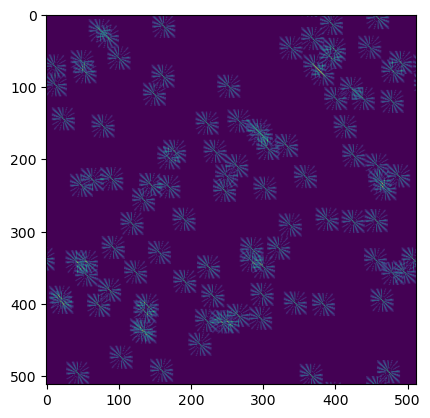

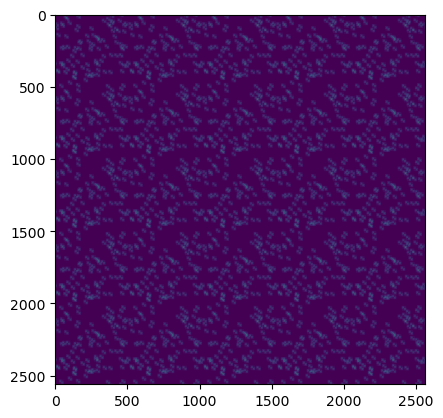

In [110]:
image_new = np.tile(image,reps=(5,5))
plt.imshow(image)
plt.show()
plt.imshow(image_new)
plt.show()

In [111]:
import scipy.sparse as sparse

In [120]:
def make_top_image(xs,ys,x,y,mag):
    z = sparse.coo_matrix((xs.shape[0],ys.shape[0])).tolil()
    for xpt,ypt,magpt in zip(x,y,mag):
        i = np.abs(xs - xpt).argmin()
        j = np.abs(ys - ypt).argmin()

        z[i,j] = magpt
    return z.tocoo()


In [121]:
xs = np.linspace(-1,1,512)
z = make_top_image(xs,xs,x,y,mag)

In [198]:
class Kernel:
    def __init__(self,low,high,theta_sigma,rsigsig,rsigloc):
        self.low = low
        self.high = high
        self.rsigsig = rsigsig
        self.rsigloc = rsigloc
        self.theta_sigma= theta_sigma

    def __call__(self,x,y):
        r_sigma = rng.normal(self.rsigloc,self.rsigsig)
        number_spikes = np.random.randint(self.low,self.high)
        return self.spike_kernel(x,y,r_sigma,number_spikes)

    def spike_kernel(self,x,y,r_sigma,number_spikes):
        epsilon=1e-6
        theta = jnp.where(jnp.isclose(x,0),jnp.arctan(y/epsilon),jnp.arctan(y/x))
            
        r = np.sqrt(x**2 + y**2)
        thetas= np.linspace(0,2*np.pi,number_spikes)
        theta_part = np.zeros(x.shape)
        for theta_dir in thetas:
            theta_part += gaussian_function((theta-theta_dir),sigma=self.theta_sigma) +  gaussian_function(-(theta-theta_dir) % 2*np.pi,sigma=self.theta_sigma)
        z = gaussian_function(r,sigma=r_sigma) * theta_part
        return z



In [202]:
def convole(Xs,Ys,z,kernel):
    out  = np.zeros(z.shape)
    x_space = np.arange(-Xs.shape[0]//2, (Xs.shape[0]+1)//2,dtype=int) 
    y_space = np.arange(-Xs.shape[1]//2, (Xs.shape[1]+1)//2,dtype=int) % Xs.shape[1]

    for r, c, v in zip(z.row, z.col, z.data):
        gen_kernel = kernel(Xs,Ys)
        # print(out[,].shape)
        rxs, rys = np.meshgrid((r+x_space)% z.shape[0],(c+x_space)% z.shape[1])
        out[rxs, rys] += v * gen_kernel

    return out
    
rng    = np.random.default_rng(42)
number_stars = 235
x = rng.uniform(-1,1,size=number_stars)
y = rng.uniform(-1,1,size=number_stars)
mag = rng.standard_normal((number_stars))*0.1 + 0.7

xs = np.linspace(-1,1,512)
z = make_top_image(xs,xs,x,y,mag)

low = 1
high = 4
theta_sigma = 0.2
rsigsig = 0.001
rsigloc = 0.01
gen_kern = Kernel(low,high,theta_sigma,rsigsig,rsigloc)
scale_down = 4
x_kern = np.linspace(-1/scale_down,1/scale_down,int(len(xs)/scale_down))
Xs, Ys = np.meshgrid(x_kern,x_kern)    
ran_conv = convole(Xs, Ys,z,gen_kern)



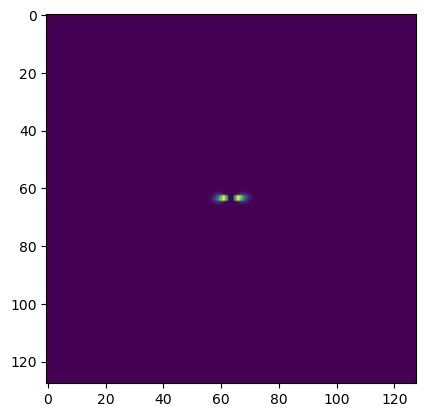

In [203]:
plt.imshow(gen_kern(Xs,Ys))
plt.show()

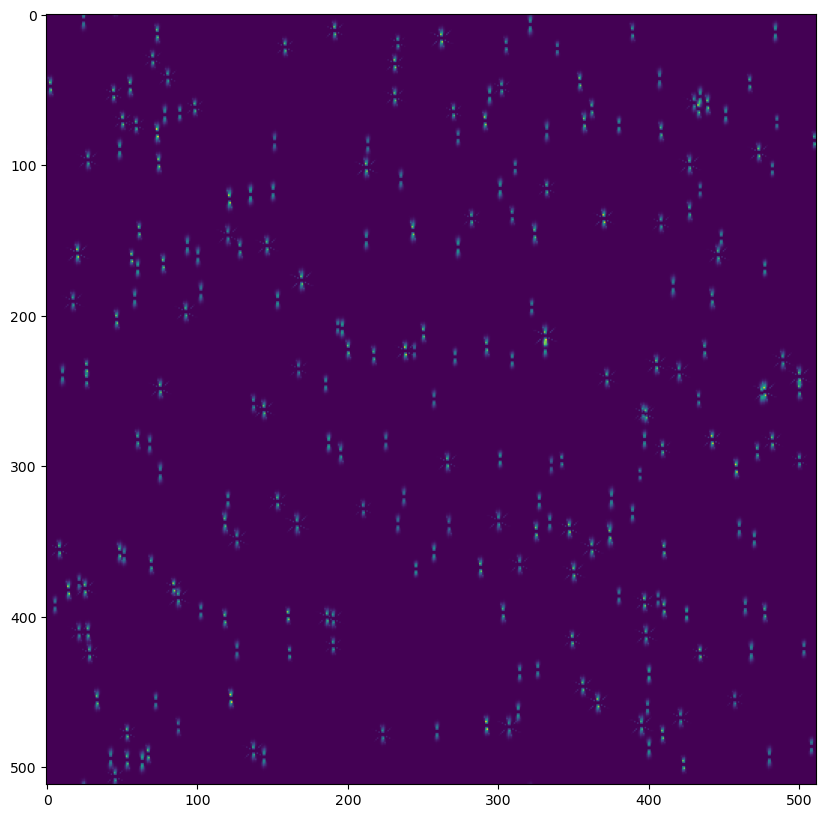

In [204]:
plt.figure(figsize=(10, 10)) 
plt.imshow(ran_conv)
plt.show()


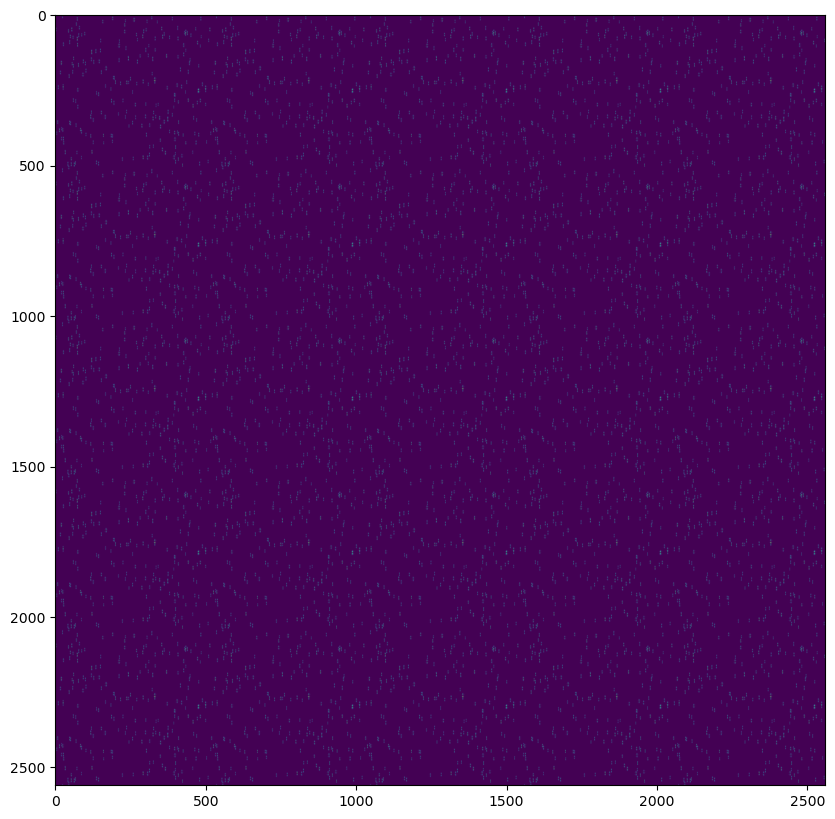

In [205]:
ran_conv_new = np.tile(ran_conv,reps=(5,5))
plt.figure(figsize=(10, 10)) 
plt.imshow(ran_conv_new)
plt.show()